In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Dataset Path
dataset_path = "../dataset/dataset/dataset-resized"

IMG_SIZE = 224
BATCH_SIZE = 32

# Data Generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# MobileNetV2 Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Training
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

# Save Model
model.save("../model/waste_model.h5")

print("✅ Model Saved Successfully!")

Found 2018 images belonging to 6 classes.
Found 502 images belonging to 6 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 891ms/step - accuracy: 0.5872 - loss: 1.0951 - val_accuracy: 0.6793 - val_loss: 0.8386
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 817ms/step - accuracy: 0.7393 - loss: 0.7062 - val_accuracy: 0.6932 - val_loss: 0.7886
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 721ms/step - accuracy: 0.7790 - loss: 0.6068 - val_accuracy: 0.7012 - val_loss: 0.7717
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 721ms/step - accuracy: 0.7944 - loss: 0.5631 - val_accuracy: 0.7331 - val_loss: 0.6684
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 817ms/step - accuracy: 0.8097 - loss: 0.4981 - val_accuracy: 0.7231 - val_loss: 0.6554
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 771ms/step - accuracy: 0.8241 - loss: 0.4759 - val_accuracy: 0.7291 - val_loss: 0.6658
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 852ms/step - accuracy: 0.8310 - loss: 0.4461 - val_accuracy: 0.7649 - val_loss: 0.6619
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 850ms/step - accuracy: 0.8389 - loss: 0.4129 - val_accu

✅ Model Saved Successfully!


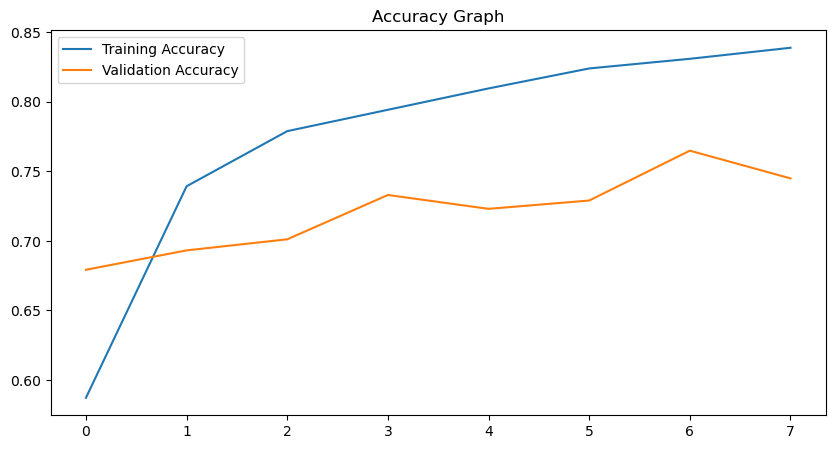

In [6]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

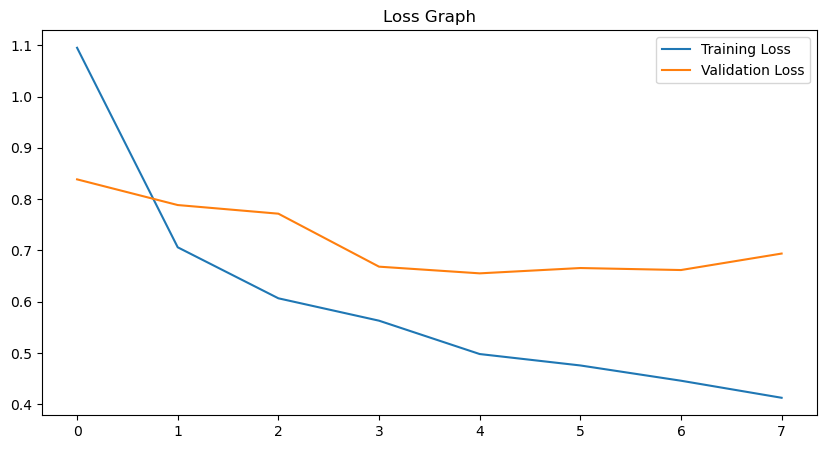

In [7]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [8]:
import os

print(os.path.exists("../model/waste_model.h5"))

True
